In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

## Section 6: Train Different Models

## Model 1: Decision Tree

In [2]:
# Import the cleaned dataset
df = pd.read_csv("../data/Cleaned_data_Q2.csv")

In [3]:
# Define features and target variable
X = df.drop(columns=['Attrition_Flag'])
y = df['Attrition_Flag']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27)

# Initialize a Decision Tree model with default parameters
clf = DecisionTreeClassifier(random_state=27)

# Train the model
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9432
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81       308
           1       0.97      0.97      0.97      1718

    accuracy                           0.94      2026
   macro avg       0.89      0.89      0.89      2026
weighted avg       0.94      0.94      0.94      2026



### Analysis of the training result from the basic decision tree
The precision (0.79) and recall (0.78) for class 0 (Attrited Customers) are relatively low, indicating that the model struggles to correctly identify customers who are likely to churn. This is likely due to class imbalance, where the number of existing customers significantly outweighs the attrited ones. To address this, we will adjust the class weight in the loss function to penalize misclassification of class 0 more heavily.

Also, we will do tuning for the other hyper-parameters. The F1 score will be used to evaluate the model, as it balances both precision and recall, making it a better metric for imbalanced datasets.

In [4]:
# Define the parameter grid
param_grid = {
    'class_weight': [None, 'balanced'],  # Adjust weight for class imbalance
    'max_depth': [2, 3, 5, 8, 10, 12, 15, None],  # Control tree depth to avoid overfitting
    'min_samples_split': [2, 3, 5, 8, 10, 15, 20],  # Minimum samples needed for a split
}

# Initialize the model
dt = DecisionTreeClassifier(random_state=42)

# Perform grid search with cross-validation
# We use 5-fold cross valudation, with scoring system as f1_macro.
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# Use the best model
dt_best_model = grid_search.best_estimator_

Best Parameters: {'class_weight': None, 'max_depth': 8, 'min_samples_split': 10}
Best F1 Score: 0.8964336921776921


### Result of Decision Tree
After using 5-fold cross validation on several combinations of hyper-parameters, we obtain that the decision tree without class weightage, max-depth of 8, and min_samples_split of 10 can achieve the best F1 score.

Now we will summarize the performance of the best decision tree model we chose.

In [45]:
# Make predictions
y_pred_best = dt_best_model.predict(X_test)

# Evaluate best model performance
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best Model Accuracy: {accuracy_best:.4f}")
print("Classification Report for Best Model:\n", classification_report(y_test, y_pred_best))

Best Model Accuracy: 0.9487
Classification Report for Best Model:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82       308
           1       0.96      0.98      0.97      1718

    accuracy                           0.95      2026
   macro avg       0.92      0.88      0.90      2026
weighted avg       0.95      0.95      0.95      2026



### Summary of the Decision Tree
The best decision tree model achieves a higher model accuracy (from 0.94 to 0.95), a higher precision for the attrited class (from 0.81 to 0.87). Although the recall score of the attrited class decreases a bit, the f1-score for the class still increases. A small recall drop may be acceptable as we wish to avoid incorrectly labeling loyal customers as attrited, which could lead to unnecessary interventions. 

Overall, we are convinced that this model is better than before.

## Model 2: Logistic Regression

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Define numerical columns (excluding one-hot encoded categorical columns)
numerical_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
                  'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 
                  'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 
                  'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

# Standardize numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Initialize Logistic Regression model with L2 regularization
log_reg = LogisticRegression(random_state=27, solver='liblinear')

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9131
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.59      0.68       308
           1       0.93      0.97      0.95      1718

    accuracy                           0.91      2026
   macro avg       0.86      0.78      0.81      2026
weighted avg       0.91      0.91      0.91      2026



### Analysis of the training result from the basic logistic regression model
Similar as the decision tree model, we notice that although the overall accuracy is relatively high (0.91), the highly imbalanced dataset still causes the f1-score, recall, and precision of class 0 to be low.

We will adopt similar approach as the decision tree, which is trying different combindations of hyper-parameters by cross validation, to try to find the best model.

In [47]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the hyperparameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 50, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'class_weight': [None,'balanced']  # Handle class imbalance
}

# Initialize the logistic regression model (use solver compatible with L1 & L2)
log_reg = LogisticRegression(solver='liblinear', random_state=27)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model results
best_lr_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validated Score: {grid_search.best_score_:.4f}")

# Evaluate on test set
y_pred = best_lr_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))



Best Parameters: {'C': 10, 'class_weight': None, 'penalty': 'l1'}
Best Cross-Validated Score: 0.8959
Test Accuracy: 0.9062
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.76      0.71       308
           1       0.96      0.93      0.94      1718

    accuracy                           0.91      2026
   macro avg       0.81      0.85      0.83      2026
weighted avg       0.91      0.91      0.91      2026



c:\Users\junji\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Summary of the Logistic Regression Model
The results indicate an improvement in the model’s ability to identify churned customers, with recall for Class 0 increasing from 59% to 76%. This means the model is now better at detecting actual churn cases. However, this improvement comes at the cost of precision, which dropped from 78% to 67%, leading to more false positives. Despite this trade-off, the overall accuracy remains high at 90.6%, and the F1-score for Class 0 has improved, suggesting a more balanced prediction.

This shift highlights the classic trade-off between recall and precision. A higher recall ensures that fewer actual churned customers are missed, which is crucial for customer retention strategies, even if it means some non-churned customers are mistakenly flagged.

## Model 3: Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest model
rf = RandomForestClassifier(random_state=27)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9645
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.84      0.88       308
           1       0.97      0.99      0.98      1718

    accuracy                           0.96      2026
   macro avg       0.95      0.91      0.93      2026
weighted avg       0.96      0.96      0.96      2026



Similar to the previous two models, we will use grid search to try to find the best combinations of hyperparameters for the random forest model.

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Define the hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [5, 10, 20, None],  # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples required in a leaf node
    'class_weight': [None, 'balanced']  # Handle class imbalance
}

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=27)

# Perform Grid Search with Cross-Validation
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

# Retrieve the best model
best_rf_model = grid_search_rf.best_estimator_

# Print the best parameters and score
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validated Score: {grid_search_rf.best_score_:.4f}")

# Evaluate on test set
y_pred_rf = best_rf_model.predict(X_test_scaled)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Best Parameters: {'class_weight': None, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validated Score: 0.9568
Test Accuracy: 0.9650
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.84      0.88       308
           1       0.97      0.99      0.98      1718

    accuracy                           0.96      2026
   macro avg       0.95      0.92      0.93      2026
weighted avg       0.96      0.96      0.96      2026



## Section 7: Visualization of Models

In [50]:
# Visualize the models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap

# 1. Decision Tree Feature Importance Visualization
def plot_decision_tree_importance(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')
    plt.title("Decision Tree Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()

# plot_decision_tree_importance(clf, X_train.columns)

# 2. Logistic Regression Coefficients Visualization
def plot_logistic_regression_coefficients(model, feature_names):
    coef = model.coef_.flatten()
    indices = np.argsort(np.abs(coef))[::-1]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=coef[indices], y=np.array(feature_names)[indices], palette='coolwarm')
    plt.axvline(x=0, color='gray', linestyle='--')
    plt.title("Logistic Regression Coefficients")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    plt.show()

# plot_logistic_regression_coefficients(best_lr_model, X_train.columns)


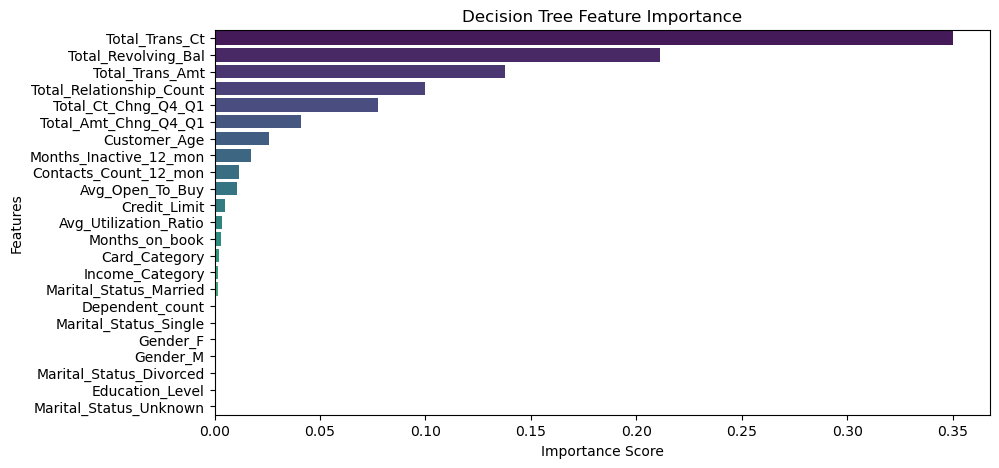

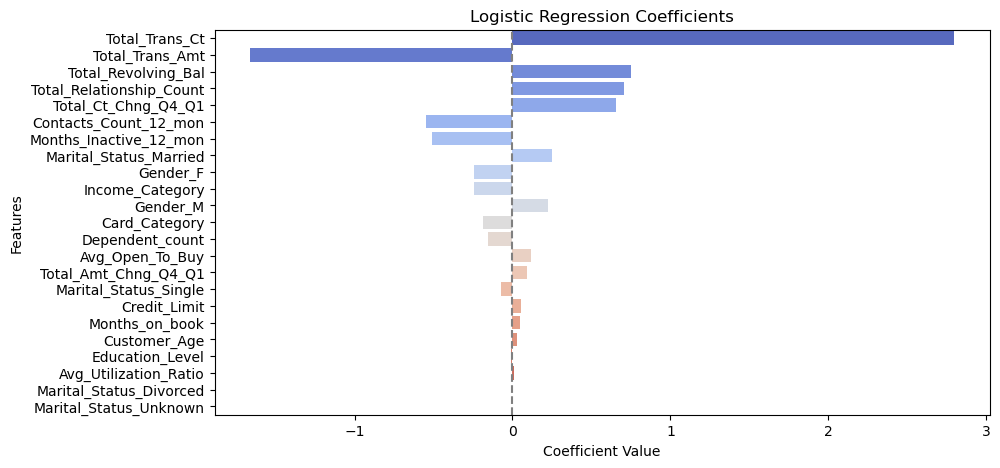

In [51]:
plot_decision_tree_importance(dt_best_model, X_train.columns) #clf
plot_logistic_regression_coefficients(best_lr_model, X_train.columns)

### Summary of visualization plots:
decision tree: total transaction count and total revolving balance are the most important features in the decision tree. Thus, customers with frequent transactions and high revolving balance are tend to retain. Also, total transaction amount and total relationship count are also influential factors, although with lower importance.
logistic regression: Similarly, those four features have the highest coefficient values. However, transaction count and transaction amount have higher absolute coefficient values than the other two factors.

## Section 8: Final Model Chosen
The Random Forest model was chosen as the final model due to its superior performance across multiple evaluation metrics. With a test accuracy of 96.5% and a best cross-validated F1 score of 0.9568, it demonstrates strong generalization. The high recall (0.99) for the positive class ensures minimal false negatives, which is crucial for customer churn prediction. Additionally, its balanced performance across precision, recall, and F1-score further supports its reliability. Given these results, Random Forest provides the best trade-off between accuracy and robustness for this task.

## The Random Forest Model is put in the py file of question A2.

In [52]:
### Train the Model using all Data
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Combine train and test data
X_full = np.vstack((X_train, X_test))
y_full = np.hstack((y_train, y_test))

# Standardize numerical features
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

# Train the final model with the best hyperparameters
final_rf_model = RandomForestClassifier(
    class_weight=None,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=100,
    random_state=27
)

final_rf_model.fit(X_full_scaled, y_full)

# Model is now fully trained on all available data
print("Final model trained on full dataset.")

Final model trained on full dataset.
